In [1]:
import pandas as pd
import zipfile
import requests
from io import BytesIO

# 1. Download and Extract
url = "https://maven-datasets.s3.amazonaws.com/Global+Electronics+Retailer/Global+Electronics+Retailer.zip"
r = requests.get(url)
z = zipfile.ZipFile(BytesIO(r.content))

# 2. Load the core tables
sales = pd.read_csv(z.open('Sales.csv'), encoding='ISO-8859-1')
products = pd.read_csv(z.open('Products.csv'), encoding='ISO-8859-1')
customers = pd.read_csv(z.open('Customers.csv'), encoding='ISO-8859-1')

# Clean Currency Columns in Products table ---
def clean_currency(column):
    # Remove '$' and ',' then convert to float
    return pd.to_numeric(column.astype(str).str.replace('$', '').str.replace(',', ''), errors='coerce')

products['Unit Price USD'] = clean_currency(products['Unit Price USD'])
products['Unit Cost USD'] = clean_currency(products['Unit Cost USD'])

# 3. Merge Data
df = sales.merge(products, on='ProductKey').merge(customers, on='CustomerKey')

# Convert Dates properly ---
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Delivery Date'] = pd.to_datetime(df['Delivery Date'])

# 4. Perform Analysis
# A) Calculate Profit
df['Profit'] = (df['Unit Price USD'] - df['Unit Cost USD']) * df['Quantity']

# B) Calculate Shipping Time (Extra Analysis)
# This handles the requested "Average Shipping Days" calculation
df['Shipping Days'] = (df['Delivery Date'] - df['Order Date']).dt.days

print("--- Analysis Results ---")
print(f"Top 5 Profitable Products:\n{df.groupby('Product Name')['Profit'].sum().nlargest(5)}")
print(f"\nAverage Shipping Time: {df['Shipping Days'].mean():.2f} days")

--- Analysis Results ---
Top 5 Profitable Products:
Product Name
WWI Desktop PC2.33 X2330 Black                 337986.00
Adventure Works Desktop PC2.33 XD233 Silver    311663.95
Adventure Works Desktop PC2.33 XD233 Brown     310368.05
Adventure Works Desktop PC2.33 XD233 Black     299352.90
Adventure Works Desktop PC2.33 XD233 White     292225.45
Name: Profit, dtype: float64

Average Shipping Time: 4.53 days


In [2]:
# Check the first few rows and column names
print("Columns in Sales:", sales.columns.tolist())
print(f"Total merged rows: {len(df)}")

# Show the top 5 most profitable products
df['Profit'] = (df['Unit Price USD'] - df['Unit Cost USD']) * df['Quantity']
top_products = df.groupby('Product Name')['Profit'].sum().nlargest(5)
print("\nTop 5 Profitable Products:")
print(top_products)

Columns in Sales: ['Order Number', 'Line Item', 'Order Date', 'Delivery Date', 'CustomerKey', 'StoreKey', 'ProductKey', 'Quantity', 'Currency Code']
Total merged rows: 62884

Top 5 Profitable Products:
Product Name
WWI Desktop PC2.33 X2330 Black                 337986.00
Adventure Works Desktop PC2.33 XD233 Silver    311663.95
Adventure Works Desktop PC2.33 XD233 Brown     310368.05
Adventure Works Desktop PC2.33 XD233 Black     299352.90
Adventure Works Desktop PC2.33 XD233 White     292225.45
Name: Profit, dtype: float64


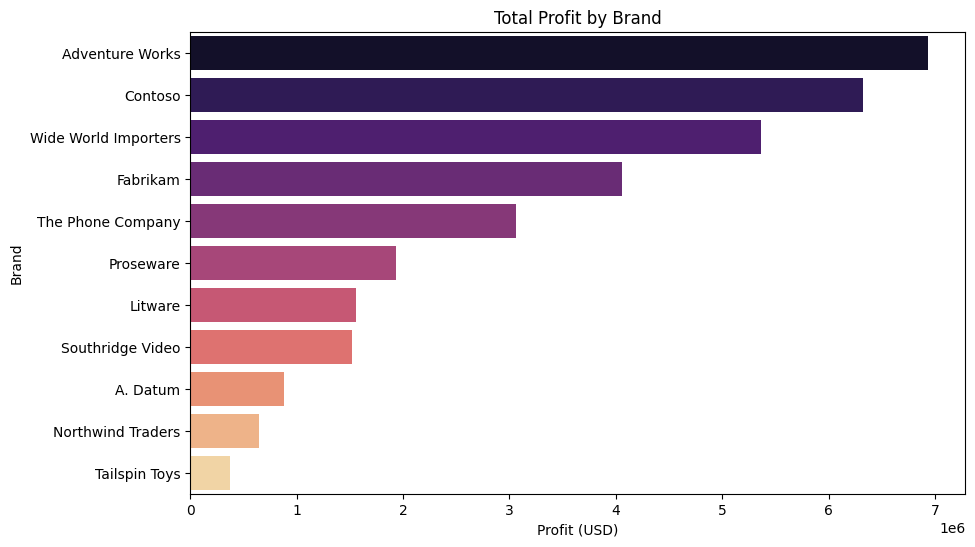

In [4]:
# Visualizing Profit by Brand
import matplotlib.pyplot as plt
import seaborn as sns

brand_profit = df.groupby('Brand')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=brand_profit.values, y=brand_profit.index, hue=brand_profit.index, palette='magma', legend=False)
plt.title('Total Profit by Brand')
plt.xlabel('Profit (USD)')
plt.show()

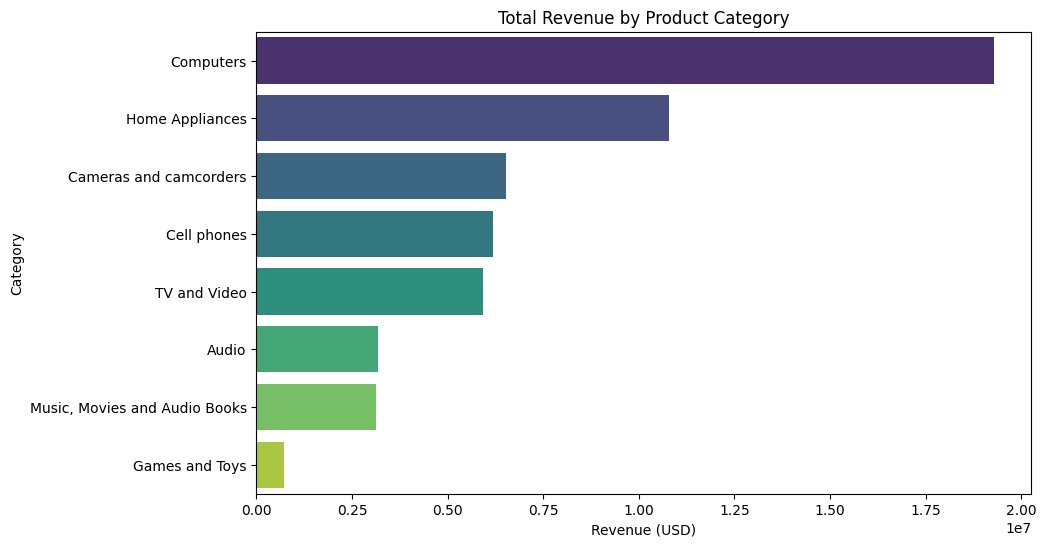

In [5]:
# Calculate Revenue
df['Revenue'] = df['Quantity'] * df['Unit Price USD']

# Group by Category
cat_revenue = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
# Assigning y to hue and setting legend=False removes the warning
sns.barplot(x=cat_revenue.values, y=cat_revenue.index, hue=cat_revenue.index, palette='viridis', legend=False)
plt.title('Total Revenue by Product Category')
plt.xlabel('Revenue (USD)')
plt.show()

/var/folders/fk/f0ym87r144g76slggx23p55m0000gn/T/ipykernel_6480/1470029181.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.set_index('Order Date')['Revenue'].resample('M').sum()


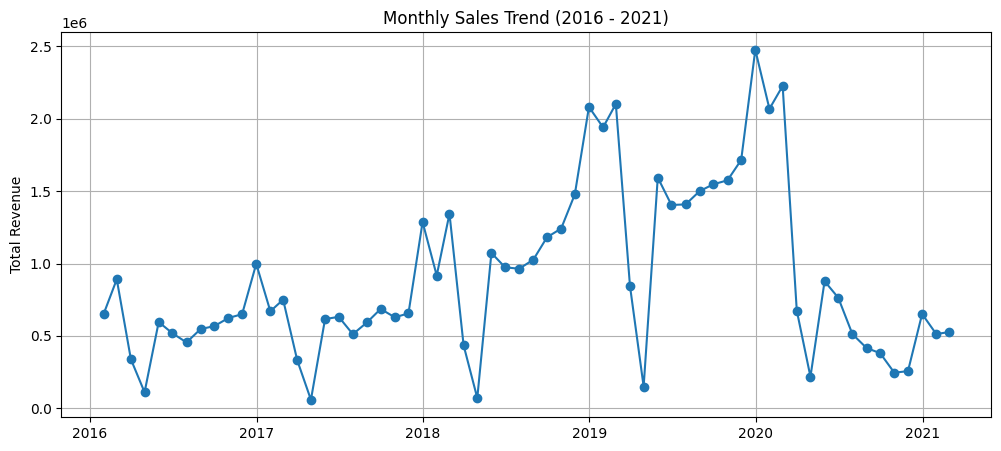

In [6]:
# Resample to see monthly trends
monthly_sales = df.set_index('Order Date')['Revenue'].resample('M').sum()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales, marker='o', color='tab:blue')
plt.title('Monthly Sales Trend (2016 - 2021)')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.show()

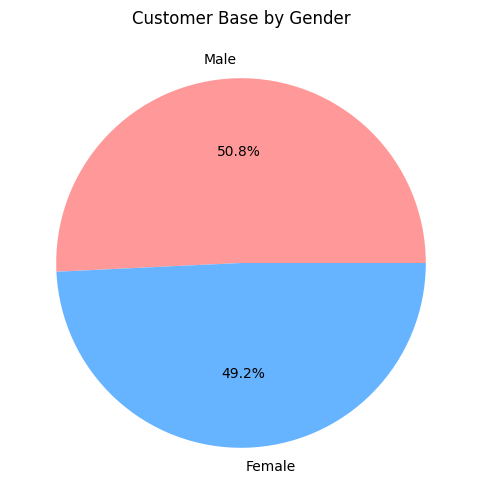

In [7]:
gender_counts = customers['Gender'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Customer Base by Gender')
plt.show()